# GFM

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [47]:
from io import BytesIO

import ocha_stratus as stratus
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from src.datasources import codab
from src.constants import *

In [14]:
adm3 = codab.load_codab_from_blob(admin_level=3)

<Axes: >

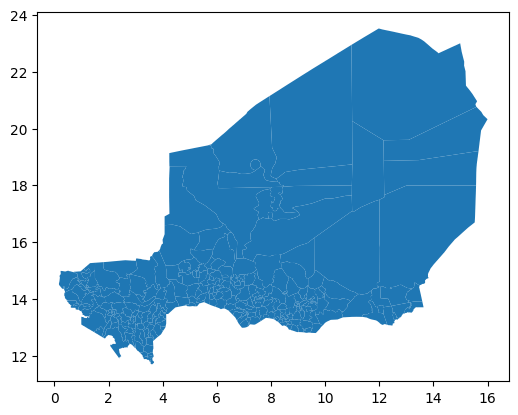

In [15]:
adm3.plot()

In [16]:
adm3["target"] = adm3["ADM3_PCODE"].isin(ADM3_AOI_PCODES_2025)

In [50]:
gfm_date_str = "2026-01-11"

In [52]:
blob_name = f"ds-flood-gfm/processed/exposed_population/ner_flooding_adm3s_{gfm_date_str.replace('-', '')}_cumulative_b100.csv"
df_exp = stratus.load_csv_from_blob(blob_name)

In [54]:
df_exp = df_exp.rename(columns={"adm3_src": "ADM3_PCODE"})

In [55]:
df_exp["target"] = df_exp["ADM3_PCODE"].isin(ADM3_AOI_PCODES_2025)

In [56]:
df_exp["target"].sum()

13

In [57]:
df_exp["color"] = df_exp["target"].map({True: "crimson", False: "grey"})

In [70]:
df_exp = df_exp.sort_values("pop_exposed")

In [71]:
df_exp

,adm3_name,ADM3_PCODE,pop_exposed,target,color
44,Inatès,NE006002002,0.0,False,grey
35,Tounouga,NE003006005,0.0,False,grey
36,Gaya,NE003006003,0.0,True,crimson
37,Torodi,NE006013002,0.0,False,grey
38,Fakara,NE003001003,0.0,False,grey
43,Bengou,NE003006002,0.0,False,grey
40,Gollé,NE003004004,0.0,False,grey
41,Yélou,NE003006006,0.0,False,grey
42,Bana,NE003006001,0.0,False,grey
39,Fabidji,NE003001002,0.0,False,grey


In [72]:
cutoff = df_exp[df_exp["target"]]["pop_exposed"].min()
if cutoff == 0:
    cutoff = 1

In [73]:
cutoff

1

In [74]:
def french_thousands(x, pos):
    return f"{int(x):,}".replace(",", "\u202f")

Text(0.5, 0, 'Commune')

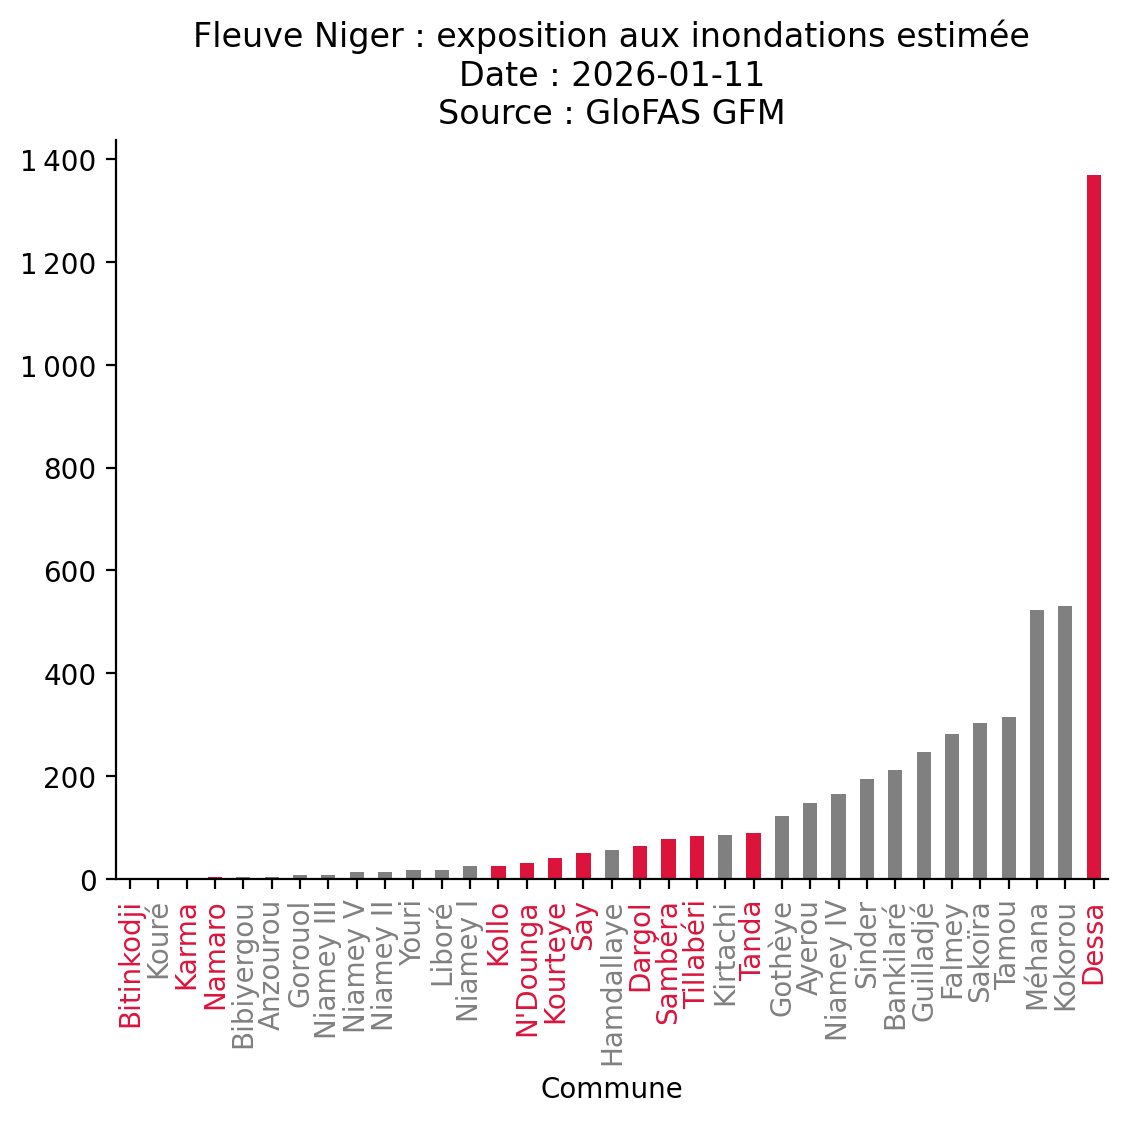

In [79]:
fig, ax = plt.subplots(dpi=200)

df_plot = df_exp[df_exp["pop_exposed"] >= cutoff]

colors = df_plot["target"].map({True: "crimson", False: "grey"})

df_plot.plot.bar(
    x="adm3_name", y="pop_exposed", color=colors, ax=ax, legend=False
)

xtick_labels = ax.get_xticklabels()
for label, color in zip(xtick_labels, colors):
    label.set_color(color)

ax.yaxis.set_major_formatter(FuncFormatter(french_thousands))
[ax.spines[x].set_visible(False) for x in ["top", "right"]]

ax.set_title(
    f"Fleuve Niger : exposition aux inondations estimée\nDate : {gfm_date_str}\nSource : GloFAS GFM"
)
ax.set_xlabel("Commune")